In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from datetime import datetime
from time import time
import time
from tqdm import trange


In [ ]:
def graph(trace1, num_equation = 0, flag = True):
    if flag:
        data_accuracy = [trace1]
        layout_accuracy = go.Layout()
        fig1 = go.Figure(data=data_accuracy, layout=layout_accuracy)
        fig1.update_layout(yaxis_title="f(x)", xaxis_title="x", title="the equation number " + str(num_equation))
        fig1.show()


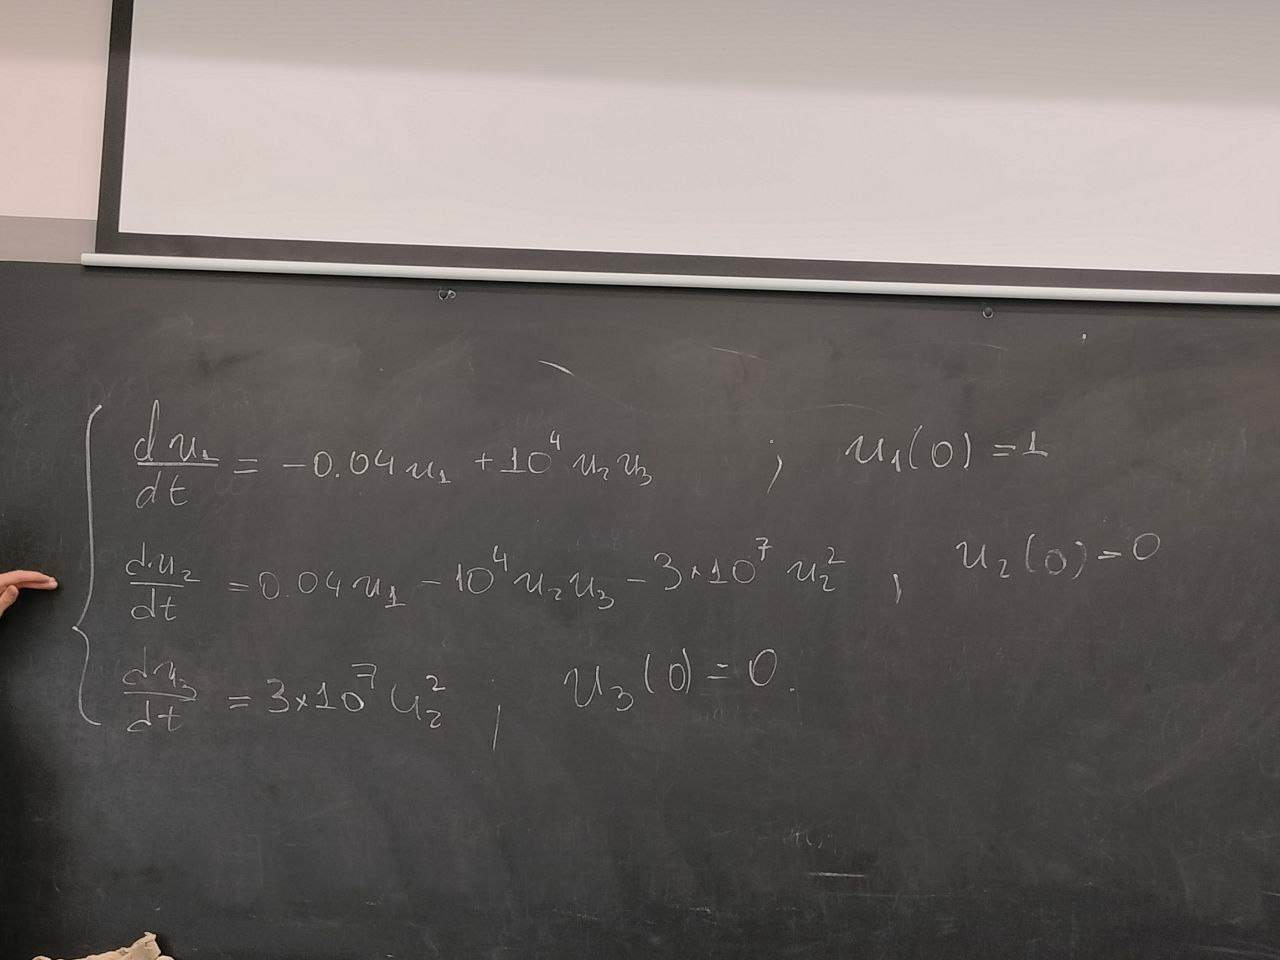

In [ ]:
def dydx_1(x, y1, y2, y3, *args):
    return (-0.04) * y1 + (10**4)* y2 * y3

def dydx_2(x, y1, y2, y3, *args):
    return (0.04) * y1 - (10**4)* y2 * y3 - 3 * (10**7) * (y2 ** 2)

def dydx_3(x, y1, y2, y3, *args):
    return 3 * (10**7) * (y2**2)

y1_0 = 1
y2_0 = 0
y3_0 = 0

dydx = np.array([dydx_1, dydx_2, dydx_3])
SOL = np.array([y1_0, y2_0, y3_0])


In [ ]:
def ExplicitEulerMethod(h, a, N, dydx, SOL):
    Y = np.array([np.zeros(N) for i in range(dydx.size)])
    x = np.zeros(N)
    
    x[0] = a
    for j in range(SOL.size):
        Y[j][0] = SOL[j]
    
    for i in trange(1, N):
        for j in range(dydx.size):
            Y[j][i] = Y[j][i-1] + h * dydx[j](x[i-1], Y[0][i-1], Y[1][i-1], Y[2][i-1]) 
        x[i] = x[i-1] + h
    
    
    
    for j in range(SOL.size):
        trace1 = go.Scatter(x=x, y=Y[j], name="approximate")
        #graph(trace1, j)

    return Y


In [ ]:
h = 0.00001
H = np.array([h / 2**i for i in range(8)])
Y = []
for hi in H:
    Y.append(ExplicitEulerMethod(hi, 0, int(3/hi), dydx, SOL))


100%|██████████| 38399999/38399999 [03:09<00:00, 203104.53it/s]


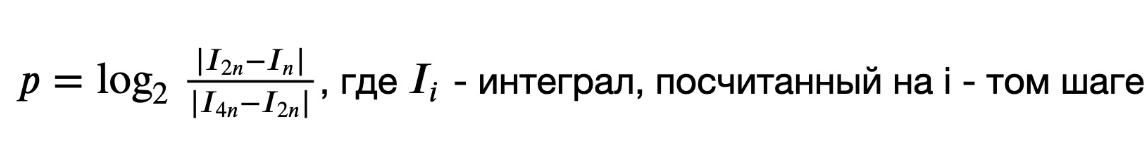

In [ ]:
p = [[],[],[]]

for i in range(3, len(Y)):
    print(H[i])
    p[0].append(np.log2(np.max(abs(Y[i - 1][0][::2] - Y[i - 2][0])) / np.max(abs(Y[i][0][::4] - Y[i-1][0][::2]))))
    p[1].append(np.log2(np.max(abs(Y[i - 1][1][::2] - Y[i - 2][1])) / np.max(abs(Y[i][1][::4] - Y[i-1][1][::2]))))
    p[2].append(np.log2(np.max(abs(Y[i - 1][2][::2] - Y[i - 2][2])) / np.max(abs(Y[i][2][::4] - Y[i-1][2][::2]))))

d_ExplicitEulerMethod = {
    "h" : H[3:len(Y)],
    "OrderOfAccuracy_y1" : p[0],
    "OrderOfAccuracy_y2" : p[1],
    "OrderOfAccuracy_y3" : p[2]
        
}
df_ExplicitEulerMethod = pd.DataFrame(d_ExplicitEulerMethod)
df_ExplicitEulerMethod


1.25e-06
6.25e-07
3.125e-07
1.5625e-07
7.8125e-08


,h,OrderOfAccuracy_y1,OrderOfAccuracy_y2,OrderOfAccuracy_y3
0,1.250000e-06,1.000009,1.001940,1.001942
1,6.250000e-07,0.999971,1.000968,1.000969
2,3.125000e-07,1.000033,1.000483,1.000484
3,1.562500e-07,0.999964,1.000241,1.000242
4,7.812500e-08,1.000059,1.000121,1.000121


# Метод Эйлера с пересчтётом

In [ ]:
def Euler_recalculation(h, a, N, dydx, SOL):
    Y = np.array([np.zeros(N) for i in range(dydx.size)])
    x = np.zeros(N)
    
    x[0] = a

    for j in range(SOL.size):
        Y[j][0] = SOL[j]
    
    for i in trange(1, N):
        for j in range(dydx.size):
            y_1 = Y[0][i-1] + h * dydx[j](x[i-1], *[Y[f][i-1] for f in range(SOL.size)])
            y_2 = Y[1][i-1] + h * dydx[j](x[i-1], *[Y[f][i-1] for f in range(SOL.size)])
            
            y_3 = Y[1][i-1] + h * dydx[j](x[i-1], *[Y[f][i-1] for f in range(SOL.size)])

            Y[j][i] = Y[j][i-1] + (h/2) * (dydx[j](x[i-1], *[Y[f][i-1] for f in range(SOL.size)]) + dydx[j](x[i-1] + h, y_1, y_2, y_3)) 
        x[i] = x[i-1] + h
    
    
    for j in range(SOL.size):
        trace1 = go.Scatter(x=x, y=Y[j], name="approximate")
        #graph(trace, j)
    
    
    return Y


In [ ]:
h = 0.00001
H = np.array([h / 2**i for i in range(8)])
Y_recalculation = []
for hi in H:
    Y_recalculation.append(Euler_recalculation(hi, 0, int(3/hi), dydx, SOL))


100%|██████████| 38399999/38399999 [17:40<00:00, 36206.08it/s]


In [ ]:
p_recalculation = [[],[],[]]

for i in range(3, len(Y_recalculation)):
    #print(H[i])
    p_recalculation[0].append(np.log2(np.max(abs(Y_recalculation[i - 1][0][::2] - Y_recalculation[i - 2][0])) / np.max(abs(Y_recalculation[i][0][::4] - Y_recalculation[i-1][0][::2]))))
    p_recalculation[1].append(np.log2(np.max(abs(Y_recalculation[i - 1][1][::2] - Y_recalculation[i - 2][1])) / np.max(abs(Y_recalculation[i][1][::4] - Y_recalculation[i-1][1][::2]))))
    p_recalculation[2].append(np.log2(np.max(abs(Y_recalculation[i - 1][2][::2] - Y_recalculation[i - 2][2])) / np.max(abs(Y_recalculation[i][2][::4] - Y_recalculation[i-1][2][::2]))))

d_recalculation = {
    "h" : H[3:len(Y_recalculation)],
    "OrderOfAccuracy_y1" : p_recalculation[0],
    "OrderOfAccuracy_y2" : p_recalculation[1],
    "OrderOfAccuracy_y3" : p_recalculation[2]
        
}
df_recalculation = pd.DataFrame(d_recalculation)
df_recalculation


,h,OrderOfAccuracy_y1,OrderOfAccuracy_y2,OrderOfAccuracy_y3
0,1.250000e-06,1.004352,0.912946,1.003798
1,6.250000e-07,1.002172,0.958509,1.001896
2,3.125000e-07,1.001085,0.979729,1.000947
3,1.562500e-07,1.000542,0.989979,1.000473
4,7.812500e-08,1.000271,0.995018,1.000237


# Метод Рунге Кутты

In [ ]:
def Runge_Kutta4(h, a, N, dydx, SOL):
    Y = np.array([np.zeros(N) for i in range(dydx.size)])
    x = np.zeros(N)
    
    x[0] = a

    for j in range(SOL.size):
        Y[j][0] = SOL[j]

    for i in trange(1, N):

        k = np.array([np.zeros(4) for _ in range(SOL.size)])

        for j in range(SOL.size):
            k[j][0] = dydx[j](x[i-1], *[Y[n][i-1] for n in range(SOL.size)])

        for j in range(1, 4):
            for n in range(SOL.size):
                if j == 3:
                    k[n][j] = dydx[n](x[i-1] + h, *[Y[m][i-1] + h*k[m][j-1] for m in range(SOL.size)])
                else:
                    k[n][j] = dydx[n](x[i-1] + 0.5*h, *[Y[m][i-1] + 0.5*h*k[m][j-1] for m in range(SOL.size)])

        for j in range(SOL.size):
            Y[j][i] = Y[j][i-1] + (h / 6) * (k[j][0] + 2*k[j][1] + 2*k[j][2] + k[j][3])

        x[i] = x[i-1] + h
    
    for j in range(SOL.size):
        trace1 = go.Scatter(x=x, y=Y[j], name="approximate")
        #graph(trace1, j)
    
    return Y


In [ ]:
h = 0.00001
H = np.array([h / 2**i for i in range(8)])
Y_RK4 = []
for hi in H:
    Y_RK4.append(Runge_Kutta4(hi, 0, int(3/hi), dydx, SOL))


100%|██████████| 38399999/38399999 [27:57<00:00, 22897.15it/s]


In [ ]:
p_RK4 = [[],[],[]]

for i in range(3, len(Y)):
    print(H[i])
    p_RK4[0].append(np.log2(np.max(abs(Y_RK4[i - 1][0][::2] - Y_RK4[i - 2][0])) / np.max(abs(Y_RK4[i][0][::4] - Y_RK4[i-1][0][::2]))))
    p_RK4[1].append(np.log2(np.max(abs(Y_RK4[i - 1][1][::2] - Y_RK4[i - 2][1])) / np.max(abs(Y_RK4[i][1][::4] - Y_RK4[i-1][1][::2]))))
    p_RK4[2].append(np.log2(np.max(abs(Y_RK4[i - 1][2][::2] - Y_RK4[i - 2][2])) / np.max(abs(Y_RK4[i][2][::4] - Y_RK4[i-1][2][::2]))))

d_RK4 = {
    "h" : H[3:len(Y)],
    "OrderOfAccuracy_y1" : p_RK4[0],
    "OrderOfAccuracy_y2" : p_RK4[1],
    "OrderOfAccuracy_y3" : p_RK4[2]
        
}
df_RK4 = pd.DataFrame(d_RK4)
df_RK4


1.25e-06
6.25e-07
3.125e-07
1.5625e-07
7.8125e-08


,h,OrderOfAccuracy_y1,OrderOfAccuracy_y2,OrderOfAccuracy_y3
0,1.250000e-06,-1.917877,4.005079,0.459698
1,6.250000e-07,0.966787,3.313294,-2.188982
2,3.125000e-07,-0.101789,0.322789,0.474430
3,1.562500e-07,-0.494406,-0.512850,-0.028254
4,7.812500e-08,-0.330328,-0.598950,0.174523


# Метод Адамса-Bashfort

In [ ]:
def Adams_Bashfort(h, a, N, dydx, SOL):
    Y = np.array([np.zeros(N) for i in range(dydx.size)])
    x = np.zeros(N)
    
    x[0] = a

    DYDX = np.array([np.zeros(N) for _ in range(SOL.size)])
    
    for j in range(SOL.size):
        Y[j][0] = SOL[j]
    
    for j in range(SOL.size):
        DYDX[j][0] = dydx[j](x[0], *[Y[n][0] for n in range(SOL.size)])

    for i in range(1, 4):

        k = np.array([np.zeros(4) for _ in range(SOL.size)])

        for j in range(SOL.size):
            k[j][0] = dydx[j](x[i-1], *[Y[n][i-1] for n in range(SOL.size)])

        for j in range(1, 4):
            for n in range(SOL.size):
                if j == 3:
                    k[n][j] = dydx[n](x[i-1] + h, *[Y[m][i-1] + h*k[m][j-1] for m in range(SOL.size)])
                else:
                    k[n][j] = dydx[n](x[i-1] + 0.5*h, *[Y[m][i-1] + 0.5*h*k[m][j-1] for m in range(SOL.size)])
        
        x[i] = x[i-1] + h
        
        for j in range(SOL.size):
            Y[j][i] = Y[j][i-1] + (h / 6) * (k[j][0] + 2*k[j][1] + 2*k[j][2] + k[j][3])
        for j in range(SOL.size):
            DYDX[j][i] = dydx[j](x[i], *[Y[n][i] for n in range(SOL.size)])

    for i in trange(4, N):
        x[i] = x[i-1] + h

        for j in range(SOL.size):
            Y[j][i] = Y[j][i-1] + (h / 24) * (
                55 * DYDX[j][i-1]
                -59 * DYDX[j][i-2]
                +37 * DYDX[j][i-3]
                -9 * DYDX[j][i-4]
            )
        for j in range(SOL.size):
            DYDX[j][i] = dydx[j](x[i], *[Y[n][i] for n in range(SOL.size)])

    for j in range(SOL.size):
        trace1 = go.Scatter(x=x, y=Y[j], name="approximate")
        #graph(trace1, j)
    
    return Y


In [ ]:
h = 0.00001
H = np.array([h / 2**i for i in range(8)])
Y_AB = []
for hi in H:
    Y_AB.append(Adams_Bashfort(hi, 0, int(3/hi), dydx, SOL))


100%|██████████| 38399996/38399996 [07:37<00:00, 84016.17it/s]


In [ ]:
p_AB = [[],[],[]]

for i in range(3, len(Y)):
    print(H[i])
    p_AB[0].append(np.log2(np.max(abs(Y_AB[i - 1][0][::2] - Y_AB[i - 2][0])) / np.max(abs(Y_AB[i][0][::4] - Y_AB[i-1][0][::2]))))
    p_AB[1].append(np.log2(np.max(abs(Y_AB[i - 1][1][::2] - Y_AB[i - 2][1])) / np.max(abs(Y_AB[i][1][::4] - Y_AB[i-1][1][::2]))))
    p_AB[2].append(np.log2(np.max(abs(Y_AB[i - 1][2][::2] - Y_AB[i - 2][2])) / np.max(abs(Y_AB[i][2][::4] - Y_AB[i-1][2][::2]))))

d_AB = {
    "h" : H[3:len(Y_AB)],
    "OrderOfAccuracy_y1" : p_AB[0],
    "OrderOfAccuracy_y2" : p_AB[1],
    "OrderOfAccuracy_y3" : p_AB[2]
        
}
df_AB = pd.DataFrame(d_AB)
df_AB


1.25e-06
6.25e-07
3.125e-07
1.5625e-07
7.8125e-08


,h,OrderOfAccuracy_y1,OrderOfAccuracy_y2,OrderOfAccuracy_y3
0,1.250000e-06,-1.921730,3.974149,3.457706
1,6.250000e-07,0.966787,3.987163,-2.190265
2,3.125000e-07,-0.101789,3.996115,0.472151
3,1.562500e-07,-0.494406,1.544665,-0.022942
4,7.812500e-08,-0.329281,-0.595964,0.174748


# Метод Adams_Bashfort_Moulton

In [ ]:
def Adams_Bashfort_Moulton(h, a, N, dydx, SOL):
    Y = np.array([np.zeros(N) for i in range(dydx.size)])
    x = np.zeros(N)
    
    x[0] = a

    DYDX = np.array([np.zeros(N) for _ in range(SOL.size)])
    
    for j in range(SOL.size):
        Y[j][0] = SOL[j]
    
    for j in range(SOL.size):
        DYDX[j][0] = dydx[j](x[0], *[Y[n][0] for n in range(SOL.size)])

    for i in range(1, 4):

        k = np.array([np.zeros(4) for _ in range(SOL.size)])

        for j in range(SOL.size):
            k[j][0] = dydx[j](x[i-1], *[Y[n][i-1] for n in range(SOL.size)])

        for j in range(1, 4):
            for n in range(SOL.size):
                if j == 3:
                    k[n][j] = dydx[n](x[i-1] + h, *[Y[m][i-1] + h*k[m][j-1] for m in range(SOL.size)])
                else:
                    k[n][j] = dydx[n](x[i-1] + 0.5*h, *[Y[m][i-1] + 0.5*h*k[m][j-1] for m in range(SOL.size)])
        
        x[i] = x[i-1] + h
        
        for j in range(SOL.size):
            Y[j][i] = Y[j][i-1] + (h / 6) * (k[j][0] + 2*k[j][1] + 2*k[j][2] + k[j][3])
        for j in range(SOL.size):
            DYDX[j][i] = dydx[j](x[i], *[Y[n][i] for n in range(SOL.size)])

    for i in trange(4, N):
        x[i] = x[i-1] + h

        y_ = np.zeros(SOL.size)

        for j in range(SOL.size):

            y_[j] = Y[j][i-1] + (h / 24) * (
            55 * DYDX[j][i-1]
            -59 * DYDX[j][i-2]
            +37 * DYDX[j][i-3]
            -9 * DYDX[j][i-4]
            )

        for j in range(SOL.size):
            Y[j][i] = Y[j][i-1] + (h / 24) * (
                9 * dydx[j](x[i-1] + h, *y_)
                +19 * DYDX[j][i-1]
                -5 * DYDX[j][i-2]
                +1 * DYDX[j][i-3]
            )
            
        for j in range(SOL.size):
            DYDX[j][i] = dydx[j](x[i], *[Y[n][i] for n in range(SOL.size)])
    
    for j in range(SOL.size):
        trace1 = go.Scatter(x=x, y=Y[j], name="approximate")
        #graph(trace1, j)

    return Y


In [ ]:
h = 0.00001
H = np.array([h / 2**i for i in range(8)])
Y_ABM = []
for hi in H:
    Y_ABM.append(Adams_Bashfort(hi, 0, int(3/hi), dydx, SOL))


100%|██████████| 38399996/38399996 [07:26<00:00, 85907.44it/s]


In [ ]:
p_ABM = [[],[],[]]

for i in range(3, len(Y)):
    print(H[i])
    p_ABM[0].append(np.log2(np.max(abs(Y_ABM[i - 1][0][::2] - Y_ABM[i - 2][0])) / np.max(abs(Y_ABM[i][0][::4] - Y_ABM[i-1][0][::2]))))
    p_ABM[1].append(np.log2(np.max(abs(Y_ABM[i - 1][1][::2] - Y_ABM[i - 2][1])) / np.max(abs(Y_ABM[i][1][::4] - Y_ABM[i-1][1][::2]))))
    p_ABM[2].append(np.log2(np.max(abs(Y_ABM[i - 1][2][::2] - Y_ABM[i - 2][2])) / np.max(abs(Y_ABM[i][2][::4] - Y_ABM[i-1][2][::2]))))

d_ABM = {
    "h" : H[3:len(Y_ABM)],
    "OrderOfAccuracy_y1" : p_ABM[0],
    "OrderOfAccuracy_y2" : p_ABM[1],
    "OrderOfAccuracy_y3" : p_ABM[2]
        
}
df_ABM = pd.DataFrame(d_ABM)
df_ABM


1.25e-06
6.25e-07
3.125e-07
1.5625e-07
7.8125e-08


,h,OrderOfAccuracy_y1,OrderOfAccuracy_y2,OrderOfAccuracy_y3
0,1.250000e-06,-1.921730,3.974149,3.457706
1,6.250000e-07,0.966787,3.987163,-2.190265
2,3.125000e-07,-0.101789,3.996115,0.472151
3,1.562500e-07,-0.494406,1.544665,-0.022942
4,7.812500e-08,-0.329281,-0.595964,0.174748
